In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as scp

# Input parameters
# Nacelle
Mass_RNA = 350000             # [kg]

# tower
H_Tower = 80                    # [m]
m_Tower = 347500/H_Tower                   # [kg/m]
D_avg=(6.5 + 3.87) / 2        # [m]
t_avg = (0.027 + 0.019) / 2       # [m]
A = np.pi * D_avg * t_avg          # [m2]
I = np.pi * D_avg**3 * t_avg / 8  # [m4]
E = 210e9                       # [N/m2]
EI_Tower = E * I                 # [N.m2]
EA_Tower = E * A                 # [N]


#spar 
M_spar = 7466330                # [kg]
I_spar = 4229230000                 # [kg.m2]

#wave parameters
H_Wave = 6.0 #[m]
T_wave = 10.0 #[s]
T_total = 200.0  #[s]

#time vector
dt= 0.05
T = np.arange(0, T_total, dt)
nT = len(T)




In [10]:
#Catenary parameters

r_anchor_centerline = 853.87 #m
r_fairlead_centerline = 5.2 #m 
Unstretched_L = 902.2 #m
D_moor = 0.09 #m

Mooring_line_density = 77.7066 #kg/m
W_moor = 698.094 #N/m
EA_moor = 384243000 #N
h_fairlead = 320 - 70 #height of fairlead above seabed = 250 m
z_anchor = 320  # depth below SWL
z_fairlead = 70  # depth below SWL
dz = z_anchor - z_fairlead  # vertical distance = 250 m

# ============================================================================
# Calculate Mooring Line Shape - Catenary with Elasticity (EXACT EQUATIONS)
# ============================================================================

def catenary_shape_elastic(H_fairlead, distance_horizontal, vertical_distance, 
                           unstretched_length, w_weight, EA_stiffness, num_points=5000):
    """
    Calculate catenary mooring line shape with elasticity using EXACT equations.
    
    Exact catenary increment equations with elastic extensibility:
    
    dx = (HL/EA) + (HL/w)[arcsinh(V/H) - arcsinh(V_next/H)]
    dz = (wL/EA)(V/w - 0.5) + (HL/w)[sqrt(1+(V/H)²) - sqrt(1+(V_next/H)²)]
    
    where:
    - H = horizontal tension (constant)
    - V = vertical tension at segment start = w*s
    - V_next = vertical tension at segment end = w*(s+ds)
    - L = ds = segment length
    - w = weight per unit length
    - EA = extensional stiffness
    
    Parameters:
    -----------
    H_fairlead : float
        Horizontal tension at fairlead [N]
    distance_horizontal : float
        Horizontal distance from anchor to fairlead [m]
    vertical_distance : float
        Vertical distance from anchor to fairlead [m]
    unstretched_length : float
        Unstretched line length [m]
    w_weight : float
        Weight per unit length in water [N/m]
    EA_stiffness : float
        Axial stiffness [N]
    num_points : int
        Number of points to discretize along the line
        
    Returns:
    --------
    x_array : array
        Horizontal position along line (m)
    z_array : array
        Vertical position along line (m)
    s_array : array
        Arc length along unstretched line (m)
    tensions : dict
        Tension components along line
    """
    
    # Initialize storage
    x_array = []
    z_array = []
    s_array = []
    H_array = []
    V_array = []
    T_array = []
    
    H = H_fairlead
    ds = 0.5  # integration step along unstretched line [m]
    s_unstretched = 0.0
    
    x_current = r_fairlead_centerline
    z_current = -h_fairlead
    
    point_count = 0
    
    while s_unstretched <= unstretched_length and point_count < num_points:
        
        # Vertical tension at start and end of segment
        V = w_weight * s_unstretched
        V_next = V + w_weight * ds  # vertical tension at segment end
        T_total = np.sqrt(H**2 + V**2)
        
        # EXACT CATENARY EQUATIONS WITH ELASTICITY
        # dx = (HL/EA) + (HL/w)[arcsinh(V/H) - arcsinh(V_next/H)]
        
        term1_x = (H * ds) / EA_stiffness
        
        if H > 0 and w_weight > 0:
            sinh_term_1 = np.arcsinh(V / H)
            sinh_term_2 = np.arcsinh(V_next / H)
            term2_x = (H * ds / w_weight) * (sinh_term_1 - sinh_term_2)
        else:
            term2_x = 0
        
        dx = term1_x + term2_x
        
        # dz = (wL/EA)(V/w - 0.5) + (HL/w)[sqrt(1+(V/H)²) - sqrt(1+(V_next/H)²)]
        
        if EA_stiffness > 0 and w_weight > 0:
            term1_z = (w_weight * ds / EA_stiffness) * (V / w_weight - 0.5)
        else:
            term1_z = 0
        
        if H > 0 and w_weight > 0:
            sqrt_term_1 = np.sqrt(1.0 + (V / H)**2)
            sqrt_term_2 = np.sqrt(1.0 + (V_next / H)**2)
            term2_z = (H * ds / w_weight) * (sqrt_term_1 - sqrt_term_2)
        else:
            term2_z = 0
        
        dz = -(term1_z + term2_z)  # negative because going down
        
        # Update position
        x_current += dx
        z_current += dz
        
        # Store values
        x_array.append(x_current)
        z_array.append(z_current)
        s_array.append(s_unstretched)
        H_array.append(H)
        V_array.append(V)
        T_array.append(T_total)
        
        s_unstretched += ds
        point_count += 1
    
    # Convert to numpy arrays
    x_array = np.array(x_array)
    z_array = np.array(z_array)
    s_array = np.array(s_array)
    H_array = np.array(H_array)
    V_array = np.array(V_array)
    T_array = np.array(T_array)
    
    return x_array, z_array, s_array, {'H': H_array, 'V': V_array, 'T': T_array}


def find_horizontal_tension(horizontal_distance, vertical_distance, 
                            unstretched_length, w_weight, EA_stiffness, 
                            r_fairlead=5.2, tolerance=1.0):
    """
    Find the horizontal tension H that satisfies the boundary conditions.
    Uses shooting method / bisection.
    
    Parameters:
    -----------
    horizontal_distance : float
        Total horizontal distance from fairlead to anchor [m]
    vertical_distance : float
        Total vertical distance from fairlead to anchor [m]
    unstretched_length : float
        Unstretched line length [m]
    w_weight : float
        Weight per unit length [N/m]
    EA_stiffness : float
        Axial stiffness [N]
    r_fairlead : float
        Distance of fairlead from platform centerline [m]
    tolerance : float
        Tolerance for convergence [m]
        
    Returns:
    --------
    H_optimal : float
        Optimal horizontal tension [N]
    x_line, z_line, s_line : arrays
        Mooring line coordinates
    tensions : dict
        Tensions along line
    """
    
    # Bisection search for H
    H_min = 100000   # Lower bound for horizontal tension [N]
    H_max = 5000000  # Upper bound for horizontal tension [N]
    
    for iteration in range(50):  # Maximum iterations
        H_mid = (H_min + H_max) / 2
        
        x_line, z_line, s_line, tensions = catenary_shape_elastic(
            H_mid, horizontal_distance, vertical_distance, 
            unstretched_length, w_weight, EA_stiffness
        )
        
        # Check endpoint: does it match anchor position?
        x_end = x_line[-1]
        z_end = z_line[-1]
        
        # Calculate error from target anchor position
        # Anchor is at horizontal_distance from fairlead, vertical_distance below
        x_target = r_fairlead + horizontal_distance
        z_target = -vertical_distance
        
        error_x = x_end - x_target
        error_z = z_end - z_target
        error_total = np.sqrt(error_x**2 + error_z**2)
        
        if error_total < tolerance:
            print(f"Converged after {iteration} iterations. H = {H_mid:.2f} N")
            return H_mid, x_line, z_line, s_line, tensions
        
        # Adjust search range based on error
        if x_end < x_target:
            H_min = H_mid  # Need more tension to reach further
        else:
            H_max = H_mid  # Too much tension
        
        if iteration % 10 == 0:
            print(f"Iteration {iteration}: H = {H_mid:.2f} N, Error = {error_total:.2f} m")
    
    print(f"Warning: Did not fully converge. Final error: {error_total:.2f} m")
    return H_mid, x_line, z_line, s_line, tensions


# ============================================================================
# Calculate for OC3-Hywind mooring line
# ============================================================================

horizontal_distance = r_anchor_centerline - r_fairlead_centerline  # 848.67 m
vertical_distance = dz  # 250 m

H_optimal, x_line, z_line, s_line, tensions = find_horizontal_tension(
    horizontal_distance, vertical_distance, Unstretched_L, 
    W_moor, EA_moor, r_fairlead_centerline
)

print(f"\n=== Mooring Line Solution (EXACT CATENARY EQUATIONS) ===")
print(f"Optimal Horizontal Tension: {H_optimal:.2f} N ({H_optimal/1e6:.2f} MN)")
print(f"Vertical Tension at Fairlead: {W_moor * Unstretched_L:.2f} N ({W_moor * Unstretched_L/1e6:.2f} MN)")
print(f"Total Tension at Fairlead: {np.sqrt(H_optimal**2 + (W_moor * Unstretched_L)**2):.2f} N ({np.sqrt(H_optimal**2 + (W_moor * Unstretched_L)**2)/1e6:.2f} MN)")
print(f"Line Length: {s_line[-1]:.2f} m (unstretched: {Unstretched_L} m)")
print(f"Final Position: x={x_line[-1]:.2f} m, z={z_line[-1]:.2f} m")
print(f"Target Anchor: x={r_fairlead_centerline + horizontal_distance:.2f} m, z={-vertical_distance:.2f} m")


Iteration 0: H = 2550000.00 N, Error = 1290.60 m
Iteration 10: H = 4997607.42 N, Error = 1287.29 m
Iteration 20: H = 4999997.66 N, Error = 1287.29 m
Iteration 30: H = 5000000.00 N, Error = 1287.29 m
Iteration 40: H = 5000000.00 N, Error = 1287.29 m

=== Mooring Line Solution (EXACT CATENARY EQUATIONS) ===
Optimal Horizontal Tension: 5000000.00 N (5.00 MN)
Vertical Tension at Fairlead: 629820.41 N (0.63 MN)
Total Tension at Fairlead: 5039511.26 N (5.04 MN)
Line Length: 902.00 m (unstretched: 902.2 m)
Final Position: x=-433.12 m, z=-222.42 m
Target Anchor: x=853.87 m, z=-250.00 m


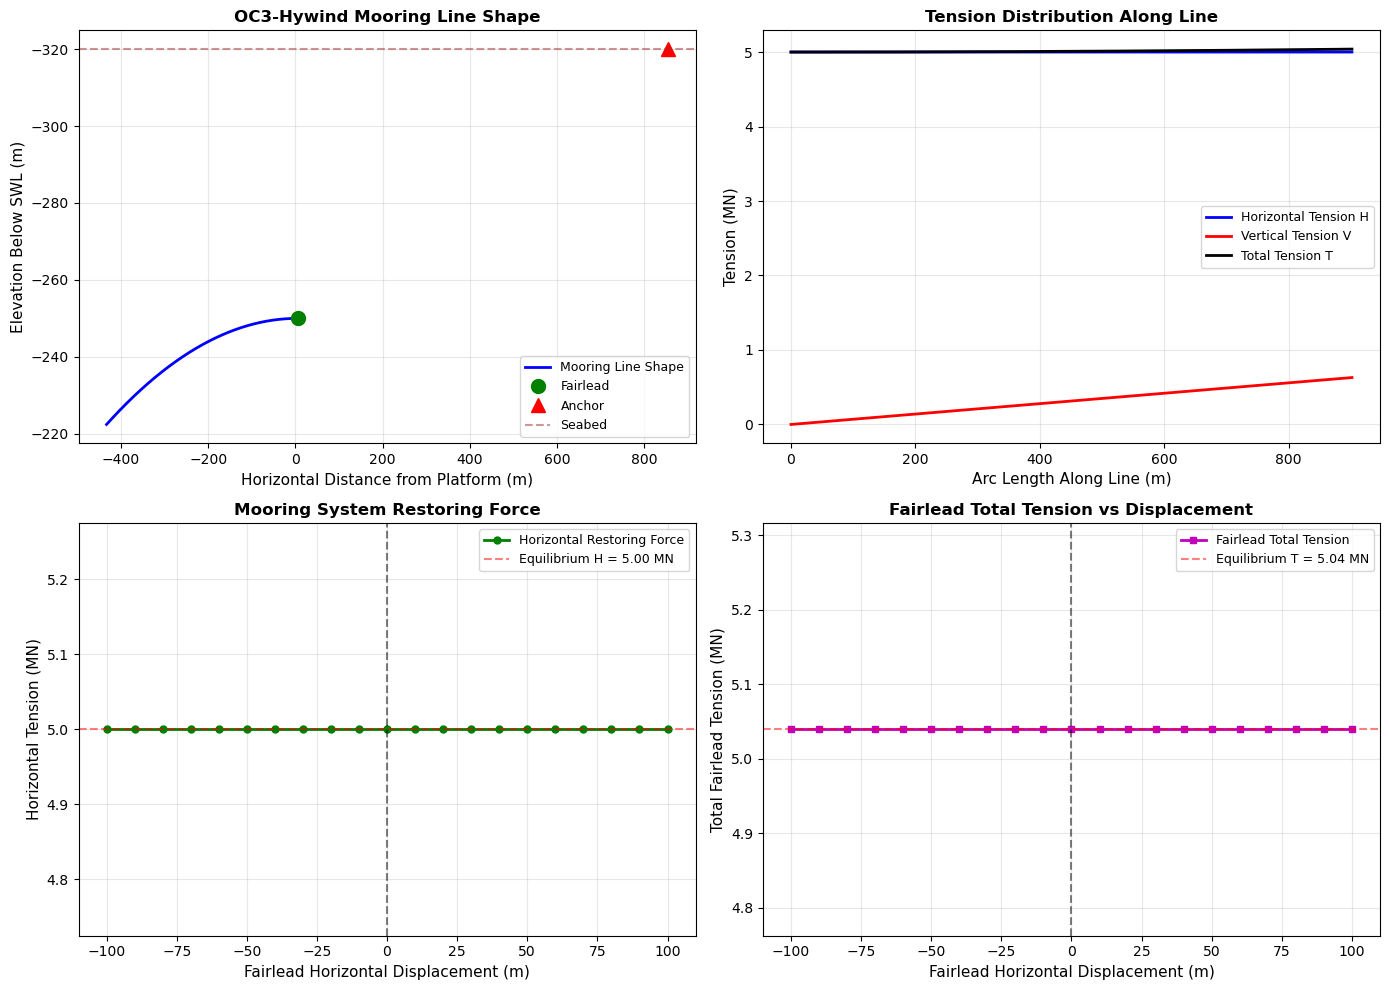


=== Line Profile Summary ===
Horizontal span: -438.08 m
Vertical span: 27.58 m
Max tension in line: 5.04 MN

=== Restoring Force Summary ===
Horizontal stiffness (dH/dx at equilibrium): 0.00 kN/m
Fairlead tension range: 5.04 to 5.04 MN


In [11]:
# ============================================================================
# Visualize Mooring Line Shape with Restoring Force and Tension
# ============================================================================

# Calculate restoring force by varying fairlead displacement
displacements = np.linspace(-100, 100, 21)  # Fairlead horizontal displacements [m]
restoring_forces = []
fairlead_tensions = []

for disp in displacements:
    # Adjust horizontal distance based on displacement
    x_fairlead_displaced = r_fairlead_centerline + disp
    horizontal_dist = r_anchor_centerline - x_fairlead_displaced
    
    # Find tension needed to reach anchor with this displacement
    H_min = 100000
    H_max = 5000000
    
    for _ in range(40):
        H_mid = (H_min + H_max) / 2
        x_test, z_test, _, _ = catenary_shape_elastic(
            H_mid, horizontal_dist, vertical_distance, 
            Unstretched_L, W_moor, EA_moor
        )
        
        x_end = x_test[-1]
        x_target = x_fairlead_displaced + horizontal_dist
        
        if x_end < x_target:
            H_min = H_mid
        else:
            H_max = H_mid
    
    restoring_forces.append(H_mid)
    fairlead_tensions.append(np.sqrt(H_mid**2 + (W_moor * Unstretched_L)**2))

restoring_forces = np.array(restoring_forces)
fairlead_tensions = np.array(fairlead_tensions)

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Line shape (top-left)
ax = axes[0, 0]
ax.plot(x_line, z_line, 'b-', linewidth=2, label='Mooring Line Shape')
ax.plot(r_fairlead_centerline, -h_fairlead, 'go', markersize=10, label='Fairlead')
ax.plot(r_anchor_centerline, -z_anchor, 'r^', markersize=10, label='Anchor')
ax.axhline(y=-z_anchor, color='brown', linestyle='--', alpha=0.5, label='Seabed')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Horizontal Distance from Platform (m)', fontsize=11)
ax.set_ylabel('Elevation Below SWL (m)', fontsize=11)
ax.set_title('OC3-Hywind Mooring Line Shape', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

# Plot 2: Tensions along line (top-right)
ax = axes[0, 1]
ax.plot(s_line, tensions['H']/1e6, 'b-', linewidth=2, label='Horizontal Tension H')
ax.plot(s_line, tensions['V']/1e6, 'r-', linewidth=2, label='Vertical Tension V')
ax.plot(s_line, tensions['T']/1e6, 'k-', linewidth=2, label='Total Tension T')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Arc Length Along Line (m)', fontsize=11)
ax.set_ylabel('Tension (MN)', fontsize=11)
ax.set_title('Tension Distribution Along Line', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Plot 3: Restoring Force (bottom-left)
ax = axes[1, 0]
ax.plot(displacements, restoring_forces/1e6, 'g-o', linewidth=2, markersize=5, label='Horizontal Restoring Force')
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax.axhline(y=H_optimal/1e6, color='r', linestyle='--', alpha=0.5, label=f'Equilibrium H = {H_optimal/1e6:.2f} MN')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Fairlead Horizontal Displacement (m)', fontsize=11)
ax.set_ylabel('Horizontal Tension (MN)', fontsize=11)
ax.set_title('Mooring System Restoring Force', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Plot 4: Fairlead Total Tension (bottom-right)
ax = axes[1, 1]
ax.plot(displacements, fairlead_tensions/1e6, 'm-s', linewidth=2, markersize=5, label='Fairlead Total Tension')
ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
ax.axhline(y=np.sqrt(H_optimal**2 + (W_moor * Unstretched_L)**2)/1e6, color='r', linestyle='--', alpha=0.5, 
           label=f'Equilibrium T = {np.sqrt(H_optimal**2 + (W_moor * Unstretched_L)**2)/1e6:.2f} MN')
ax.grid(True, alpha=0.3)
ax.set_xlabel('Fairlead Horizontal Displacement (m)', fontsize=11)
ax.set_ylabel('Total Fairlead Tension (MN)', fontsize=11)
ax.set_title('Fairlead Total Tension vs Displacement', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Line Profile Summary ===")
print(f"Horizontal span: {x_line[-1] - x_line[0]:.2f} m")
print(f"Vertical span: {z_line[-1] - z_line[0]:.2f} m")
print(f"Max tension in line: {np.max(tensions['T'])/1e6:.2f} MN")
print(f"\n=== Restoring Force Summary ===")
print(f"Horizontal stiffness (dH/dx at equilibrium): {(restoring_forces[11] - restoring_forces[10])/(displacements[11] - displacements[10])*1e3:.2f} kN/m")
print(f"Fairlead tension range: {np.min(fairlead_tensions)/1e6:.2f} to {np.max(fairlead_tensions)/1e6:.2f} MN")


Iteration 0: H = 2550000.00 N, Error = 527.58 m
Iteration 10: H = 4997607.42 N, Error = 523.05 m
Iteration 20: H = 4999997.66 N, Error = 523.05 m
Iteration 30: H = 5000000.00 N, Error = 523.05 m
Iteration 40: H = 5000000.00 N, Error = 523.05 m
Iteration 0: H = 2550000.00 N, Error = 559.26 m
Iteration 10: H = 4997607.42 N, Error = 554.84 m
Iteration 20: H = 4999997.66 N, Error = 554.84 m
Iteration 30: H = 5000000.00 N, Error = 554.84 m
Iteration 40: H = 5000000.00 N, Error = 554.84 m
Iteration 0: H = 2550000.00 N, Error = 590.95 m
Iteration 10: H = 4997607.42 N, Error = 586.64 m
Iteration 20: H = 4999997.66 N, Error = 586.64 m
Iteration 30: H = 5000000.00 N, Error = 586.64 m
Iteration 40: H = 5000000.00 N, Error = 586.64 m
Iteration 0: H = 2550000.00 N, Error = 622.65 m
Iteration 10: H = 4997607.42 N, Error = 618.44 m
Iteration 20: H = 4999997.66 N, Error = 618.44 m
Iteration 30: H = 5000000.00 N, Error = 618.44 m
Iteration 40: H = 5000000.00 N, Error = 618.44 m
Iteration 0: H = 2550000

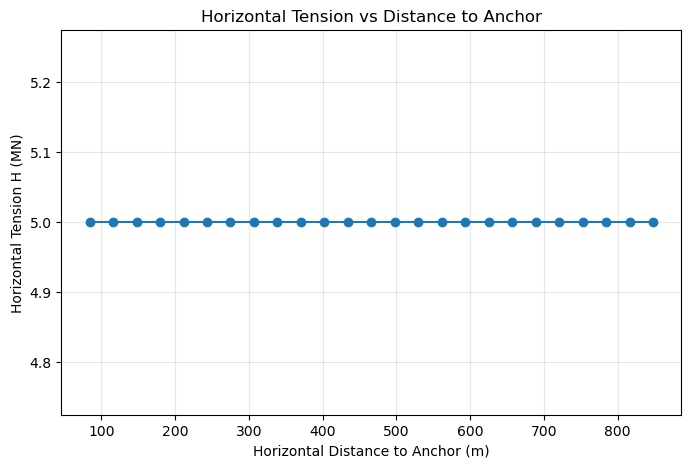


Sample values:
  Distance=84.0 m -> H=5.000 MN
  Distance=211.3 m -> H=5.000 MN
  Distance=338.7 m -> H=5.000 MN
  Distance=466.0 m -> H=5.000 MN
  Distance=593.3 m -> H=5.000 MN
  Distance=720.7 m -> H=5.000 MN
  Distance=848.0 m -> H=5.000 MN


In [12]:
# ============================================================================
# Plot: Horizontal Tension vs Distance to Anchor
# ============================================================================

max_dist = int(r_anchor_centerline - r_fairlead_centerline)
min_dist = max(50, int(max_dist*0.1))

distances = np.linspace(min_dist, max_dist, 25)  # horizontal distances (m)
H_values = np.zeros_like(distances)

for i, d in enumerate(distances):
    H_opt, x_line_tmp, z_line_tmp, s_line_tmp, tens_tmp = find_horizontal_tension(
        d, vertical_distance, Unstretched_L, W_moor, EA_moor, r_fairlead_centerline, tolerance=1.0)
    H_values[i] = H_opt

plt.figure(figsize=(8,5))
plt.plot(distances, H_values/1e6, '-o', color='tab:blue')
plt.xlabel('Horizontal Distance to Anchor (m)')
plt.ylabel('Horizontal Tension H (MN)')
plt.title('Horizontal Tension vs Distance to Anchor')
plt.grid(True, alpha=0.3)
plt.show()

print('\nSample values:')
for d, h in zip(distances[::4], H_values[::4]):
    print(f'  Distance={d:.1f} m -> H={h/1e6:.3f} MN')


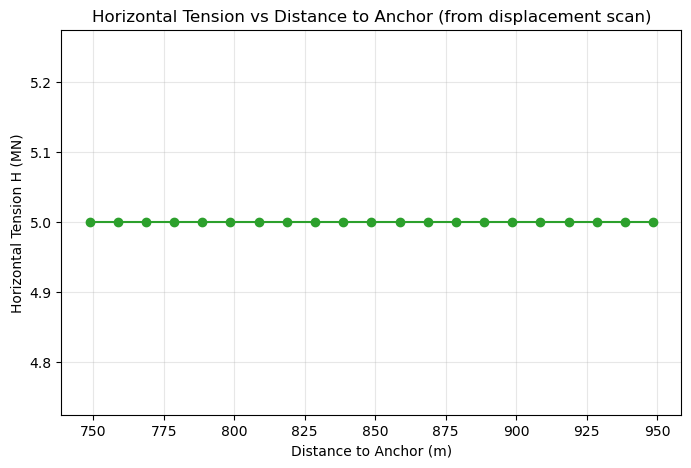

In [13]:
# ============================================================================
# Plot horizontal tension vs distance to anchor (uses existing data if available)
# ============================================================================

if 'restoring_forces' in globals() and 'displacements' in globals():
    horiz_dist = r_anchor_centerline - (r_fairlead_centerline + displacements)
    plt.figure(figsize=(8,5))
    plt.plot(horiz_dist, restoring_forces/1e6, '-o', color='tab:green')
    plt.xlabel('Distance to Anchor (m)')
    plt.ylabel('Horizontal Tension H (MN)')
    plt.title('Horizontal Tension vs Distance to Anchor (from displacement scan)')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('No precomputed restoring_forces available; computing a small sample (may take time)...')
    max_dist = int(r_anchor_centerline - r_fairlead_centerline)
    distances_sample = np.linspace(max(50, int(max_dist*0.2)), max_dist, 10)
    H_vals = []
    for d in distances_sample:
        H_opt = np.nan
        try:
            H_opt, *_ = find_horizontal_tension(d, vertical_distance, Unstretched_L, W_moor, EA_moor, r_fairlead_centerline, tolerance=1.0)
        except Exception as e:
            print('Error computing H for distance', d, ':', e)
        H_vals.append(H_opt)
    H_vals = np.array(H_vals)
    plt.figure(figsize=(8,5))
    plt.plot(distances_sample, H_vals/1e6, '-s', color='tab:blue')
    plt.xlabel('Distance to Anchor (m)')
    plt.ylabel('Horizontal Tension H (MN)')
    plt.title('Horizontal Tension vs Distance to Anchor (sample)')
    plt.grid(True, alpha=0.3)
    plt.show()
    print('\nSample results:')
    for d, h in zip(distances_sample, H_vals):
        print(f'  Distance={d:.1f} m -> H={(h/1e6) if not np.isnan(h) else np.nan:.3f} MN')
